In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

In [6]:
# Environment setup
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0
gamma = 0.9
alpha = 0.1
episodes = 50
actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
arrow_dict = {'U': (0, 0.3), 'D': (0, -0.3), 'L': (-0.3, 0), 'R': (0.3, 0)}

In [7]:
# Next state based on action
def get_next_state(state, action):
    delta = action_to_delta[action]
    next_state = (state[0] + delta[0], state[1] + delta[1])
    if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
        return next_state
    return state

# Epsilon-greedy action selection
def choose_action(state, Q, epsilon=0.1):
    if random.random() < epsilon:
        return random.choice(actions)
    i, j = state
    return actions[np.argmax(Q[i, j])]

# SARSA: On-policy TD control
def sarsa_learning():
    Q = np.zeros(grid_size + (len(actions),))
    for ep in range(episodes):
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))
        action = choose_action(state, Q)
        done = False
        while not done:
            next_state = get_next_state(state, action)
            reward = rewards[next_state]
            next_action = choose_action(next_state, Q)
            a_idx = actions.index(action)
            next_a_idx = actions.index(next_action)
            Q[state][a_idx] += alpha * (reward + gamma * Q[next_state][next_a_idx] - Q[state][a_idx])
            if next_state in terminal_states:
                done = True
            state = next_state
            action = next_action
    return Q

# Q-Learning: Off-policy TD control
def q_learning():
    Q = np.zeros(grid_size + (len(actions),))
    for ep in range(episodes):
        state = (random.randint(0, 3), random.randint(0, 3))
        while state in terminal_states:
            state = (random.randint(0, 3), random.randint(0, 3))
        done = False
        while not done:
            action = choose_action(state, Q)
            next_state = get_next_state(state, action)
            reward = rewards[next_state]
            a_idx = actions.index(action)
            Q[state][a_idx] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][a_idx]) # Greedy Assumption
            if next_state in terminal_states:
                done = True
            state = next_state
    return Q

In [8]:
# Plot policy arrows
def plot_policy(Q, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    V = np.max(Q, axis=-1)
    policy = np.full(grid_size, '', dtype=object)

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if (i, j) in terminal_states:
                policy[i, j] = 'T'
            else:
                best_action = actions[np.argmax(Q[i, j])]
                policy[i, j] = best_action
            ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
            ax.text(j + 0.5, grid_size[0]-1-i + 0.4, f"{V[i, j]:.2f}", ha='center', fontsize=8)
            if policy[i, j] != 'T':
                dx, dy = arrow_dict[policy[i, j]]
                ax.arrow(j + 0.5 - dx/2, grid_size[0]-1-i + 0.5 - dy/2, dx, dy,
                         head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

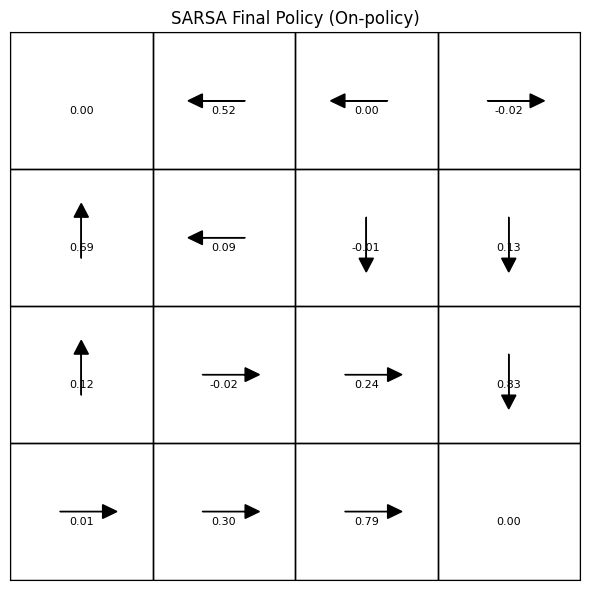

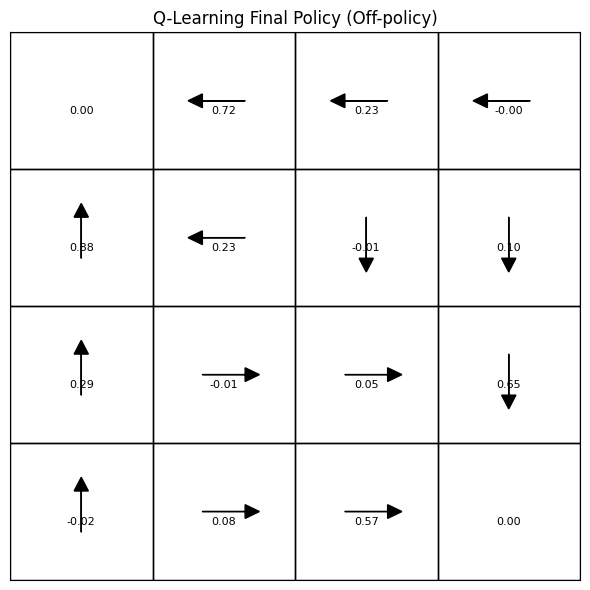

In [9]:
# Run learning algorithms
Q_sarsa = sarsa_learning()
Q_qlearn = q_learning()

# Plot final policies
plot_policy(Q_sarsa, "SARSA Final Policy (On-policy)")
plot_policy(Q_qlearn, "Q-Learning Final Policy (Off-policy)")